# CSCI 5832 Project
### By Jay Bentley

For this project, I will be creating a model for detecting phishing within email contents.

I will also be using a pretrained BERT model and I will be fine tuning the BERT model on my dataset and comparing how well the fine tuning did in addressing the model shortcomings.

I will be using this [dataset](https://huggingface.co/datasets/cybersectony/PhishingEmailDetectionv2.0)

In [42]:
%pip install datasets transformers torch scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from transformers import BertTokenizer, BertModel
import pandas as pd
import os

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import Dataset

In [3]:

splits = {'train': 'data/train-00000-of-00001.parquet', 'validation': 'data/validation-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
training_data = pd.read_parquet("hf://datasets/cybersectony/PhishingEmailDetectionv2.0/" + splits["train"])
validation_data = pd.read_parquet("hf://datasets/cybersectony/PhishingEmailDetectionv2.0/" + splits["validation"])
test_data = pd.read_parquet("hf://datasets/cybersectony/PhishingEmailDetectionv2.0/" + splits["test"])
print(training_data)

                                                  content  label
0                                https://www.galvnews.com      2
1       https://filedn.com/l0kwbcnxzlkqbihn1fmjrk4/fee...      3
2       http://www.www--wellsfargo--com--tj49329d48d6c...      3
3                           http://www.sleamcommulnity.ru      3
4                              http://www.chihabidine.com      3
...                                                   ...    ...
119995    https://old-firefly-ec6a.fefefefef.workers.dev/      3
119996  met a family in our parent-baby group with a s...      0
119997                       https://www.democratcafe.com      2
119998  https://bafybeibtzwk4n6aishsypwnt3w5b7wmqeft7g...      3
119999  gtv - 2 status files attached are the notes an...      0

[120000 rows x 2 columns]


# Data Visualization

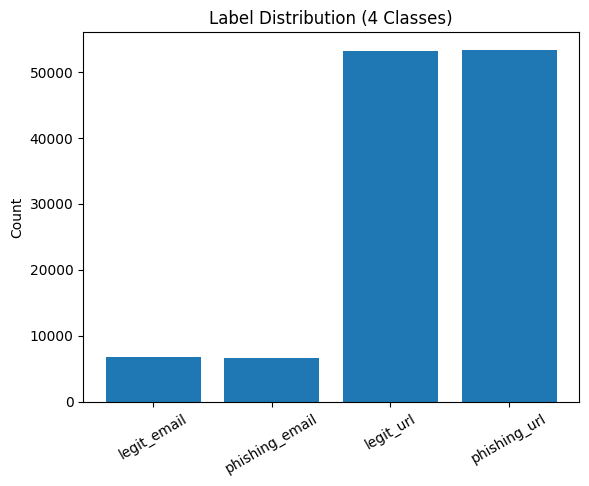

In [29]:
import matplotlib.pyplot as plt
from collections import Counter

labels = training_data["label"]
counts = Counter(labels)

class_names = [
    "legit_email",
    "phishing_email",
    "legit_url",
    "phishing_url"
]

plt.figure()
plt.bar(class_names, [counts[i] for i in range(4)])
plt.xticks(rotation=30)
plt.title("Label Distribution (4 Classes)")
plt.ylabel("Count")
plt.show()

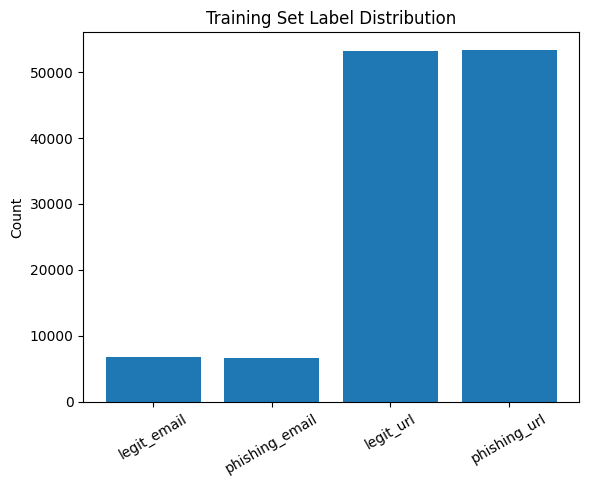

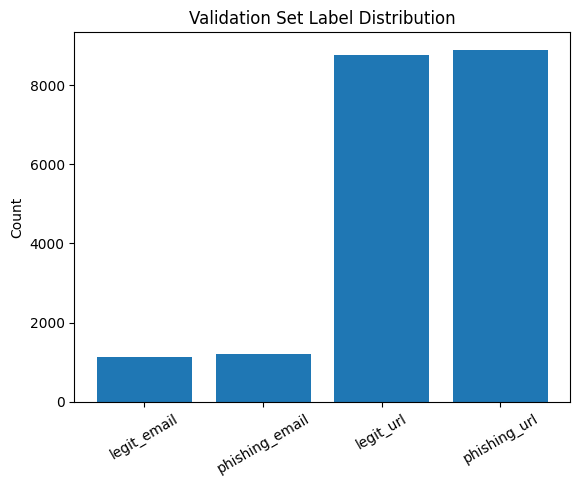

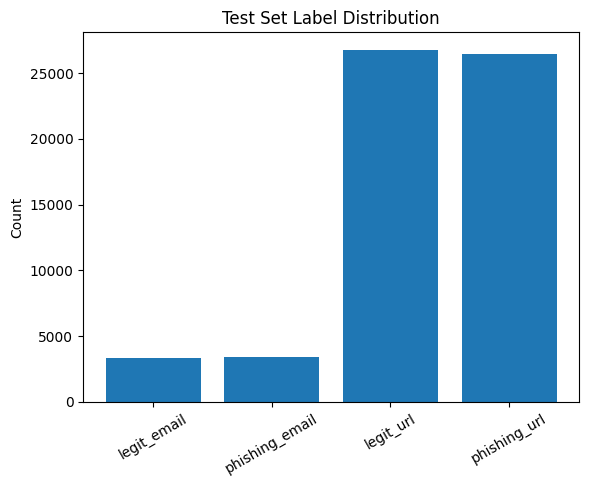

In [27]:
import matplotlib.pyplot as plt
from collections import Counter

class_names = [
    "legit_email",
    "phishing_email",
    "legit_url",
    "phishing_url"
]

def plot_distribution(dataset, title):
    labels = dataset["label"]
    counts = Counter(labels)

    plt.figure()
    plt.bar(class_names, [counts[i] for i in range(4)])
    plt.xticks(rotation=30)
    plt.title(title)
    plt.ylabel("Count")
    plt.show()

# Plot for each split
plot_distribution(training_data, "Training Set Label Distribution")
plot_distribution(validation_data, "Validation Set Label Distribution")
plot_distribution(test_data, "Test Set Label Distribution")

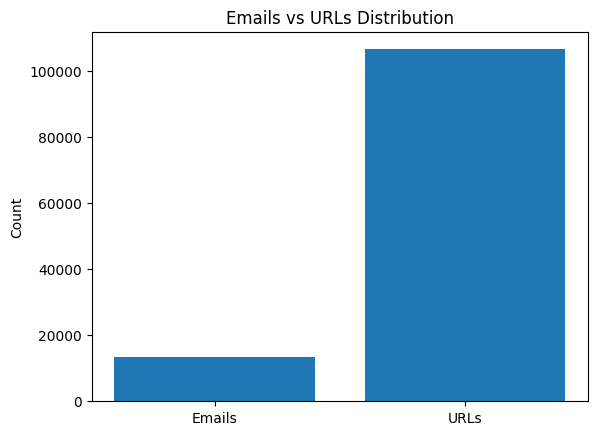

In [10]:
email_count = counts[0] + counts[1]
url_count = counts[2] + counts[3]

plt.figure()
plt.bar(["Emails", "URLs"], [email_count, url_count])
plt.title("Emails vs URLs Distribution")
plt.ylabel("Count")
plt.show()

In [12]:
import re

def is_url(text):
    return text.startswith("http") or "." in text and " " not in text

url_like = sum(is_url(t) for t in training_data["content"])
print("Detected URL-like entries:", url_like)

Detected URL-like entries: 106566


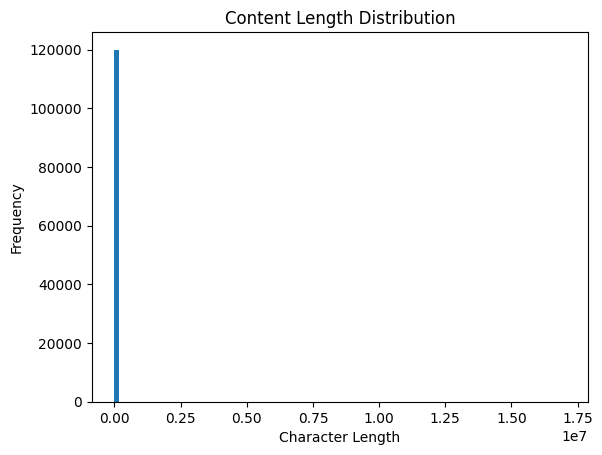

In [13]:
lengths = [len(t) for t in training_data["content"]]

plt.figure()
plt.hist(lengths, bins=100)
plt.title("Content Length Distribution")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()

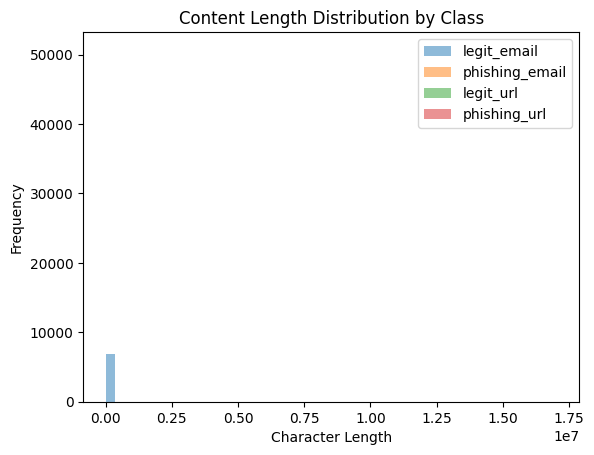

In [38]:
import matplotlib.pyplot as plt

class_names = [
    "legit_email",
    "phishing_email",
    "legit_url",
    "phishing_url"
]

lengths_by_class = {i: [] for i in range(4)}

for i, text in enumerate(training_data["content"]):
    label = training_data["label"].iloc[i]
    lengths_by_class[label].append(len(text))

plt.figure()

for i in range(4):
    plt.hist(
        lengths_by_class[i],
        bins=50,
        alpha=0.5,
        label=class_names[i]
    )

plt.legend()
plt.title("Content Length Distribution by Class")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()

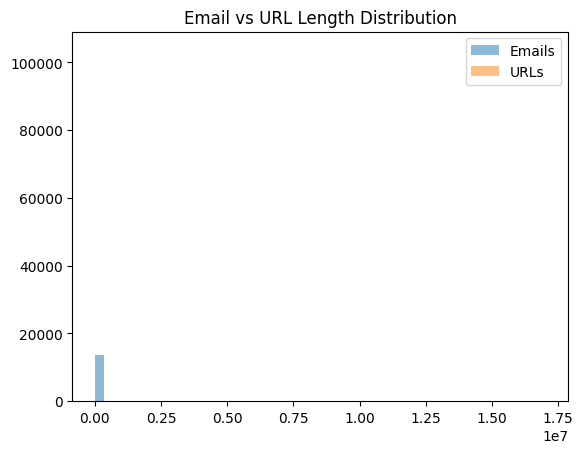

In [40]:
email_lengths = []
url_lengths = []

for i, text in enumerate(training_data["content"]):
    label = training_data["label"].iloc[i]
    
    if label in [0, 1]:
        email_lengths.append(len(text))
    else:
        url_lengths.append(len(text))

plt.figure()
plt.hist(email_lengths, bins=50, alpha=0.5, label="Emails")
plt.hist(url_lengths, bins=50, alpha=0.5, label="URLs")
plt.legend()
plt.title("Email vs URL Length Distribution")
plt.show()

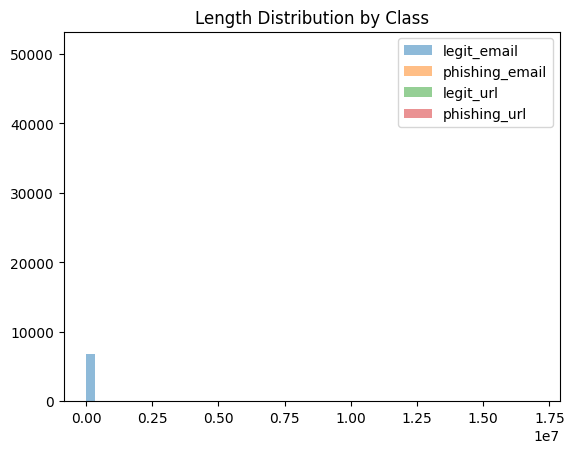

In [14]:
lengths_by_class = {i: [] for i in range(4)}

for i, text in enumerate(training_data["content"]):
    lengths_by_class[labels[i]].append(len(text))

plt.figure()
for i in range(4):
    plt.hist(lengths_by_class[i], bins=50, alpha=0.5, label=class_names[i])

plt.legend()
plt.title("Length Distribution by Class")
plt.show()

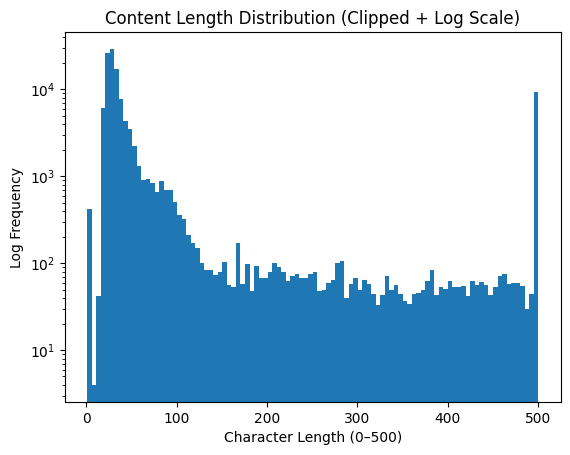

In [45]:
import numpy as np
import matplotlib.pyplot as plt

lengths = [len(t) for t in training_data["content"]]

# Clip extreme outliers (keeps detail)
clipped_lengths = np.clip(lengths, 0, 500)

plt.figure()
plt.hist(clipped_lengths, bins=100)
plt.yscale("log")  # key fix
plt.title("Content Length Distribution (Clipped + Log Scale)")
plt.xlabel("Character Length (0–500)")
plt.ylabel("Log Frequency")
plt.show()

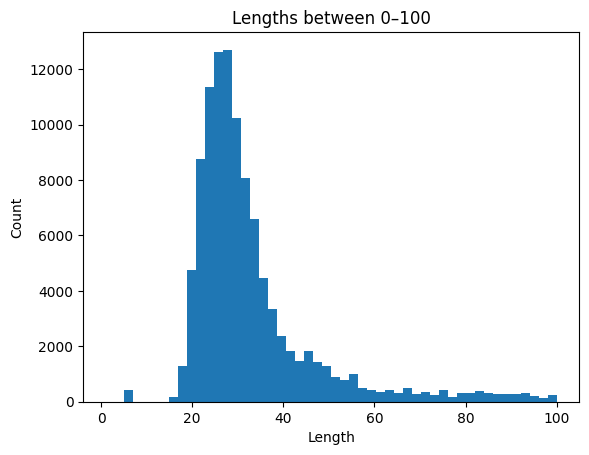

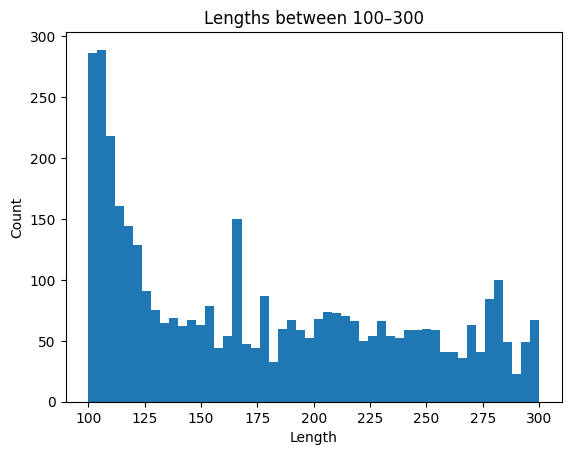

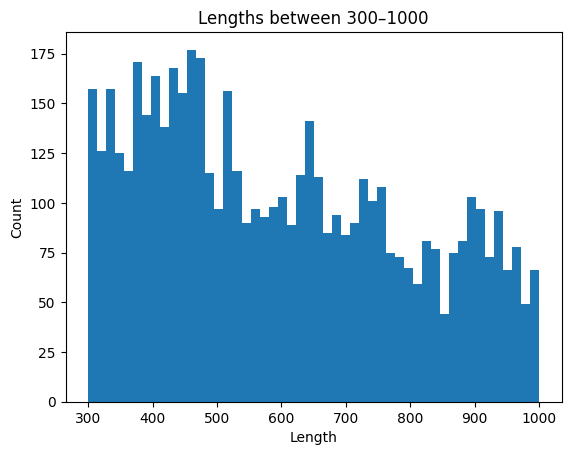

In [46]:
ranges = [(0,100), (100,300), (300,1000)]

for low, high in ranges:
    subset = [l for l in lengths if low <= l <= high]
    
    plt.figure()
    plt.hist(subset, bins=50)
    plt.title(f"Lengths between {low}–{high}")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.show()

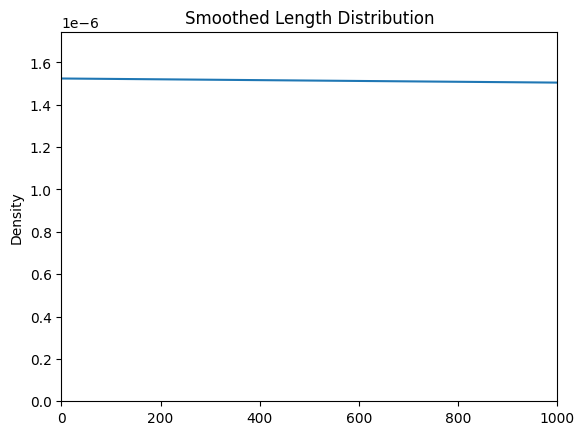

In [47]:
import seaborn as sns

sns.kdeplot(lengths, bw_adjust=0.5)
plt.xlim(0, 1000)
plt.title("Smoothed Length Distribution")
plt.show()

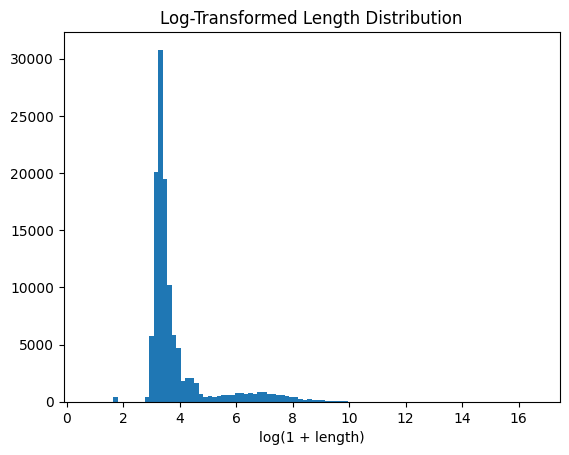

In [48]:
log_lengths = np.log1p(lengths)

plt.figure()
plt.hist(log_lengths, bins=100)
plt.title("Log-Transformed Length Distribution")
plt.xlabel("log(1 + length)")
plt.show()

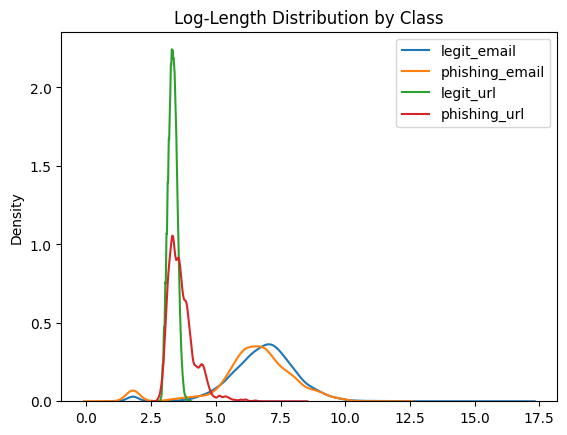

In [50]:
class_names = ["legit_email", "phishing_email", "legit_url", "phishing_url"]

plt.figure()

for i in range(4):
    class_lengths = [
        len(training_data["content"].iloc[j])
        for j in range(len(training_data))
        if training_data["label"].iloc[j] == i
    ]
    
    sns.kdeplot(np.log1p(class_lengths), label=class_names[i])

plt.legend()
plt.title("Log-Length Distribution by Class")
plt.show()

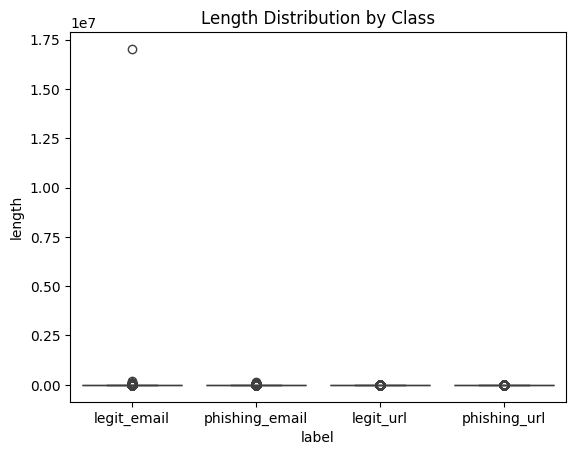

In [44]:
import seaborn as sns
import pandas as pd

df = training_data.copy()
df["length"] = df["content"].apply(len)

sns.boxplot(x="label", y="length", data=df)
plt.xticks([0,1,2,3], class_names)
plt.title("Length Distribution by Class")
plt.show()

In [15]:
import re
from collections import Counter

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

email_counter = Counter()

for i, text in enumerate(training_data["content"]):
    if labels[i] in [0, 1]:  # emails only
        email_counter.update(tokenize(text))

print(email_counter.most_common(20))

[('the', 240718), ('_', 214747), ('of', 155198), ('to', 144320), ('and', 139776), ('a', 101544), ('in', 95943), ('for', 66387), ('you', 60023), ('is', 59538), ('i', 45660), ('on', 45348), ('that', 44291), ('â', 42552), ('this', 42443), ('be', 39724), ('it', 35097), ('s', 33773), ('with', 33576), ('are', 31173)]


In [16]:
url_texts = [
    training_data["content"][i]
    for i in range(len(labels)) if labels[i] in [2, 3]
]

avg_length = sum(len(u) for u in url_texts) / len(url_texts)
print("Average URL length:", avg_length)

# count suspicious patterns
def has_ip(url):
    return bool(re.search(r"\d+\.\d+\.\d+\.\d+", url))

def has_at(url):
    return "@" in url

print("URLs with IP:", sum(has_ip(u) for u in url_texts))
print("URLs with @:", sum(has_at(u) for u in url_texts))

Average URL length: 36.74217657055405
URLs with IP: 388
URLs with @: 764


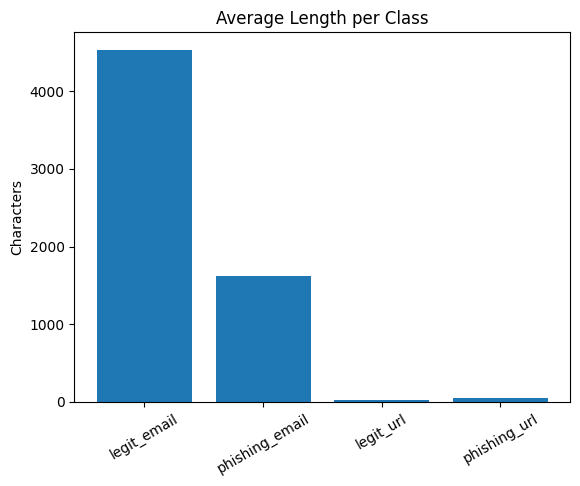

In [17]:
import numpy as np

means = [np.mean(lengths_by_class[i]) for i in range(4)]

plt.figure()
plt.bar(class_names, means)
plt.title("Average Length per Class")
plt.ylabel("Characters")
plt.xticks(rotation=30)
plt.show()

## Train my own simple Logistic Regression model

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Extract data
texts = training_data["content"]
labels = training_data["label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# Vectorize
vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Evaluate
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1374
           1       0.96      0.97      0.97      1366
           2       0.99      1.00      0.99     10560
           3       1.00      0.99      0.99     10700

    accuracy                           0.99     24000
   macro avg       0.98      0.98      0.98     24000
weighted avg       0.99      0.99      0.99     24000



In [23]:
email_data = training_data[training_data["label"].isin([0, 1])]
url_data   = training_data[training_data["label"].isin([2, 3])]

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Extract data
texts = email_data["content"]
labels = email_data["label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# Vectorize
vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Evaluate
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1395
           1       0.97      0.98      0.97      1304

    accuracy                           0.97      2699
   macro avg       0.97      0.97      0.97      2699
weighted avg       0.97      0.97      0.97      2699



In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Extract data
texts = url_data["content"]
labels = url_data["label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# Vectorize
vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Evaluate
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.99      1.00      0.99     10534
           3       1.00      0.99      0.99     10768

    accuracy                           0.99     21302
   macro avg       0.99      0.99      0.99     21302
weighted avg       0.99      0.99      0.99     21302



# Train a Random Forest Model

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

In [34]:
texts = training_data["content"]
labels = training_data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

In [35]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [36]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1362
           1       0.96      0.98      0.97      1337
           2       0.99      1.00      0.99     10631
           3       1.00      0.99      0.99     10670

    accuracy                           0.99     24000
   macro avg       0.98      0.98      0.98     24000
weighted avg       0.99      0.99      0.99     24000



In [38]:
import re
import numpy as np

def extract_features(texts):
    features = []
    
    for t in texts:
        features.append([
            len(t),  # length
            int("http" in t),
            int("@" in t),
            int(bool(re.search(r"\d+\.\d+\.\d+\.\d+", t))),  # IP
            t.count("/"),
            t.count("-"),
        ])
    
    return np.array(features)

X_train_extra = extract_features(X_train)
X_test_extra = extract_features(X_test)

In [39]:
from scipy.sparse import hstack

X_train_combined = hstack([X_train_tfidf, X_train_extra])
X_test_combined = hstack([X_test_tfidf, X_test_extra])

In [40]:
model.fit(X_train_combined, y_train)

y_pred = model.predict(X_test_combined)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1362
           1       0.95      0.97      0.96      1337
           2       1.00      1.00      1.00     10631
           3       1.00      1.00      1.00     10670

    accuracy                           0.99     24000
   macro avg       0.98      0.98      0.98     24000
weighted avg       0.99      0.99      0.99     24000



# Train a Simple Neural Network

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from sklearn.model_selection import train_test_split

In [19]:
texts = training_data["content"]
labels = training_data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

In [20]:
from collections import Counter
import re

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

counter = Counter()
for text in X_train:
    counter.update(tokenize(text))

vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(20000))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

def encode(text, max_len=200):
    tokens = tokenize(text)
    ids = [vocab.get(t, 1) for t in tokens][:max_len]
    ids += [0] * (max_len - len(ids))
    return ids

In [27]:
class EmailDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts.iloc[idx]     # ✅ FIX HERE
        label = self.labels.iloc[idx]   # ✅ FIX HERE

        return {
            "input_ids": torch.tensor(encode(text), dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long)
        }

train_dataset = EmailDataset(X_train, y_train)
test_dataset = EmailDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [28]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden*2)
        weights = torch.softmax(self.attn(lstm_output), dim=1)
        context = (weights * lstm_output).sum(dim=1)
        return context

In [33]:
class PhishingModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        
        self.attention = Attention(hidden_dim)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 4)   # ✅ 4 classes
        )

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        lstm_out, _ = self.lstm(x)
        attn_out = self.attention(lstm_out)
        return self.fc(attn_out)

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PhishingModel(len(vocab)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train():
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [35]:
from sklearn.metrics import accuracy_score

def evaluate():
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids)
            predictions = torch.argmax(outputs, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    return accuracy_score(true, preds)

In [36]:
for epoch in range(5):
    loss = train()
    acc = evaluate()
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

Epoch 1: Loss=0.0776, Accuracy=0.9899
Epoch 2: Loss=0.0292, Accuracy=0.9930
Epoch 3: Loss=0.0233, Accuracy=0.9924
Epoch 4: Loss=0.0194, Accuracy=0.9932
Epoch 5: Loss=0.0189, Accuracy=0.9934


## Fine tune BERT model

In [59]:
%pip install transformers datasets torch scikit-learn 'accelerate>=1.1.0'

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# training_data is your pandas DataFrame
df = training_data[["content", "label"]].copy()

# train/test split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# convert to Hugging Face format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["content"],
        truncation=True,
        padding="max_length",
        max_length=128   # IMPORTANT: good for URLs + emails
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map: 100%|██████████| 24000/24000 [00:08<00:00, 2674.30 examples/s] 


In [6]:
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9079.57it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [63]:
%pip install "transformers[torch]"

Note: you may need to restart the kernel to use updated packages.


In [9]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    # log_dir="./logs",   # updated param
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
)

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    # tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.005281,0.021613,0.995792,0.995791,0.995822,0.995792
2,0.012238,0.020936,0.996000,0.996000,0.996020,0.996000
3,0.000470,0.025595,0.995917,0.995916,0.995936,0.995917


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.31it/s]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.60it/s]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.67it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNor

TrainOutput(global_step=18000, training_loss=0.017889349817970975, metrics={'train_runtime': 8616.5625, 'train_samples_per_second': 33.424, 'train_steps_per_second': 2.089, 'total_flos': 1.897591006052352e+16, 'train_loss': 0.017889349817970975, 'epoch': 3.0})

In [15]:
# trainer.evaluate()
trainer.predict(test_dataset)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


PredictionOutput(predictions=array([[-3.6444554 , -3.836393  ,  7.88389   ,  0.29866692],
       [-2.818552  , -2.9648678 , -2.3038938 ,  9.463282  ],
       [-2.7175426 , -3.019456  , -2.3917654 ,  9.488431  ],
       ...,
       [-3.6817687 , -3.805457  ,  7.8652706 ,  0.3063759 ],
       [-2.8861787 , -3.1249297 , -2.1266682 ,  9.520287  ],
       [-3.5352101 , -3.8527393 ,  7.8763576 ,  0.1837892 ]],
      shape=(24000, 4), dtype=float32), label_ids=array([2, 3, 3, ..., 2, 3, 2], shape=(24000,)), metrics={'test_loss': 0.02095525898039341, 'test_accuracy': 0.996, 'test_f1': 0.9959995273612596, 'test_precision': 0.9960195612062418, 'test_recall': 0.996, 'test_runtime': 120.9019, 'test_samples_per_second': 198.508, 'test_steps_per_second': 12.407})